# 00 - Setup & Verification
AC-PINN Project | Authors: Suyash Vasal Jain, Nishita Raghvendra

Verifies environment, GPU, and all base classes work correctly.

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-r','../requirements.txt','-q'])

CompletedProcess(args=['d:\\PINN\\ac-pinn-project\\ac-pinn-project\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-r', '../requirements.txt', '-q'], returncode=0)

In [2]:
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, CurriculumSampler,
    PINNSolver, ACPINNSolver,
    BurgersFDM, HeatFDM, WaveFDM, AllenCahnFDM,
    Benchmark
)
print('All imports OK')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

All imports OK
PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU


## Smoke test - Burgers FDM

BurgersFDM solved in 0.0193s


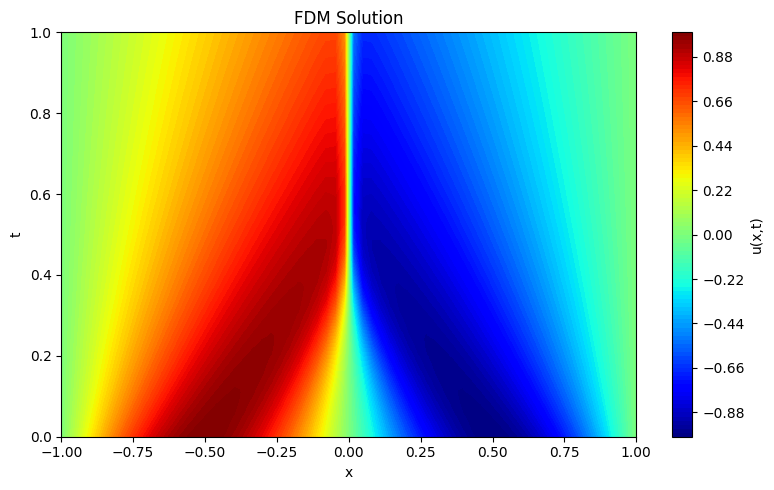

BurgersFDM OK


In [3]:
fdm = BurgersFDM(nx=64, nt=200)
fdm.solve()
fdm.plot_solution()
print('BurgersFDM OK')

## Smoke test - NoisyDataGenerator

In [4]:
gen = NoisyDataGenerator(pde='burgers')
data = gen.generate(N_ic=50, N_bc=50, N_f=200, noise_eps=0.1)
for k,v in data.items():
    print(f'{k}: {v.shape}')
print('NoisyDataGenerator OK')

x_ic: torch.Size([50, 1])
t_ic: torch.Size([50, 1])
u_ic: torch.Size([50, 1])
x_bc_left: torch.Size([25, 1])
t_bc_left: torch.Size([25, 1])
u_bc_left: torch.Size([25, 1])
x_bc_right: torch.Size([25, 1])
t_bc_right: torch.Size([25, 1])
u_bc_right: torch.Size([25, 1])
x_f: torch.Size([200, 1])
t_f: torch.Size([200, 1])
NoisyDataGenerator OK


## Smoke test - PINNSolver (10 epochs)

In [5]:
gen  = NoisyDataGenerator(pde='burgers')
data = gen.generate(N_ic=50, N_bc=50, N_f=200)
model = PINNSolver(pde='burgers', layers=[2,16,16,1])
history = model.fit(data, epochs=10, print_every=5)
print('PINNSolver OK')

Epoch     0 | Total: 0.750313 | IC: 0.284551 | BC: 0.150417 | PDE: 0.063069
Epoch     5 | Total: 0.524103 | IC: 0.296669 | BC: 0.092290 | PDE: 0.027029

Training complete in 0.21s
PINNSolver OK


d:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## Smoke test - ACPINNSolver (10 epochs)

In [6]:
ac = ACPINNSolver(pde='burgers', layers=[2,16,16,1], weight_strategy='ratio')
history = ac.fit(data, epochs=10, print_every=5)
print('ACPINNSolver OK')

Epoch     0 | Stage 1/4 | Total: 0.518795 | IC: 0.508801 | BC: 0.008912 | PDE: 0.000217 | λ=(1.00,1.00,5.00)
Epoch     5 | Stage 2/4 | Total: 0.428420 | IC: 0.418068 | BC: 0.004269 | PDE: 0.001217 | λ=(1.00,1.00,5.00)

AC-PINN training complete in 0.10s
ACPINNSolver OK


## All checks passed - ready to run experiments